## 1.&nbsp;Setup & load results

In [7]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"


# ============================================================
# PLOTTING ORDER
# ============================================================

MODEL_ORDER = [
    "baseline_raw_windows",
    "window_features",
    "temporal_features",
    "ml_features",
]

MODEL_LABELS = {
    "baseline_raw_windows": "Raw window baseline",
    "window_features": "Window features",
    "temporal_features": "Temporal features",
    "ml_features": "ML features",
}

In [9]:
# ============================================================
# LOAD MODELING RESULTS
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# Locate project root robustly
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "data" / "processed").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_RESULTS_DIR = PROCESSED_DIR / "model_results"

print("Project root:")
print(PROJECT_ROOT)

print("\nModel results directory:")
print(MODEL_RESULTS_DIR)

# ------------------------------------------------------------
# Check directory
# ------------------------------------------------------------

if not MODEL_RESULTS_DIR.exists():
    raise FileNotFoundError(
        f"Model results directory does not exist:\n{MODEL_RESULTS_DIR}"
    )

# ------------------------------------------------------------
# Load results
# ------------------------------------------------------------

default_results = pd.read_parquet(
    MODEL_RESULTS_DIR / "default_model_results.parquet"
)

optimization_results = pd.read_parquet(
    MODEL_RESULTS_DIR / "hyperparameter_results.parquet"
)

best_configurations = pd.read_parquet(
    MODEL_RESULTS_DIR / "best_configurations.parquet"
)

threshold_results = pd.read_parquet(
    MODEL_RESULTS_DIR / "threshold_results.parquet"
)

final_test_results = pd.read_parquet(
    MODEL_RESULTS_DIR / "final_test_results.parquet"
)

# ------------------------------------------------------------
# Display shapes
# ------------------------------------------------------------

print("\nLoaded result files:")
print(f"Default models:       {default_results.shape}")
print(f"Hyperparameters:      {optimization_results.shape}")
print(f"Best configurations:  {best_configurations.shape}")
print(f"Thresholds:           {threshold_results.shape}")
print(f"Final test:           {final_test_results.shape}")

Project root:
c:\Users\flori\WBS Coding School\Final Project

Model results directory:
c:\Users\flori\WBS Coding School\Final Project\data\processed\model_results

Loaded result files:
Default models:       (4, 13)
Hyperparameters:      (144, 10)
Best configurations:  (4, 9)
Thresholds:           (4, 9)
Final test:           (4, 13)


## 2.&nbsp;Final model comparison

In [10]:
# ============================================================
# PREPARE FINAL-TEST RESULTS
# ============================================================

final_test_plot = final_test_results.copy()

final_test_plot["model_label"] = (
    final_test_plot["model"]
    .map(MODEL_LABELS)
)

final_test_plot["model"] = pd.Categorical(
    final_test_plot["model"],
    categories=MODEL_ORDER,
    ordered=True,
)

final_test_plot = (
    final_test_plot
    .sort_values("model")
    .reset_index(drop=True)
)

final_test_plot[
    [
        "model",
        "AUPRC",
        "Precision",
        "Recall",
        "F1",
    ]
]

,model,AUPRC,Precision,Recall,F1
0,baseline_raw_windows,0.455106,0.346972,0.740582,0.472548
1,window_features,0.707932,0.566711,0.734589,0.639821
2,temporal_features,0.769519,0.734423,0.615582,0.669772
3,ml_features,0.750472,0.415148,0.877568,0.563651


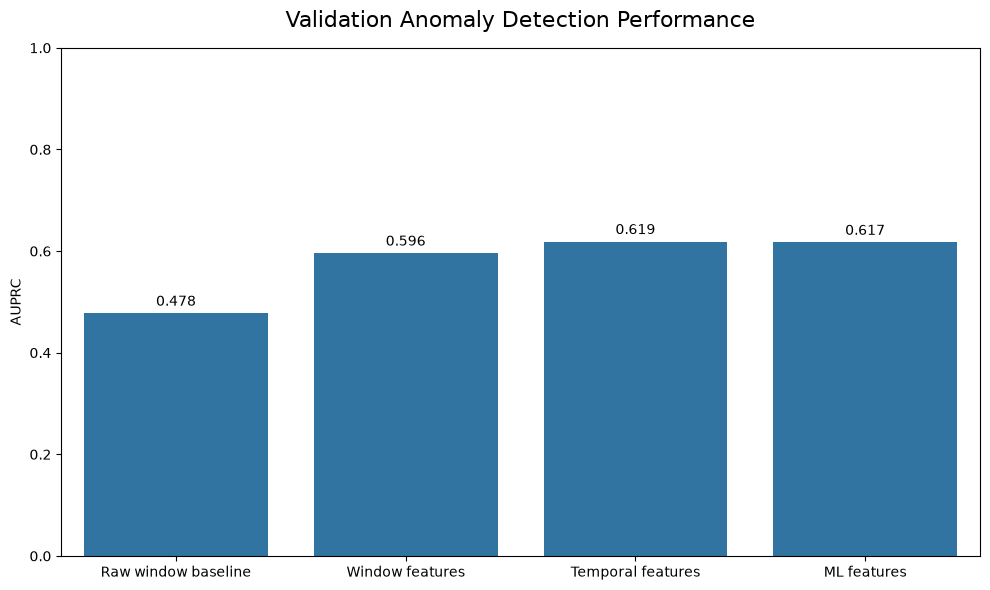

In [18]:
# ============================================================
# VALIDATION AUPRC
# ============================================================

# Get the best validation AUPRC for each model
validation_auprc = (
    optimization_results
    .groupby("model", as_index=False)["AUPRC"]
    .max()
)

validation_plot = (
    validation_auprc
    .assign(
        model_label=lambda df: df["model"].map(MODEL_LABELS)
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=validation_plot,
    x="model_label",
    y="AUPRC",
    order=[
        MODEL_LABELS[m]
        for m in MODEL_ORDER
    ],
    ax=ax,
)

ax.set_title(
    "Validation Anomaly Detection Performance",
    fontsize=16,
    pad=15,
)

ax.set_xlabel("")
ax.set_ylabel("AUPRC")

ax.set_ylim(0, 1)

ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
    )

plt.tight_layout()
plt.show()

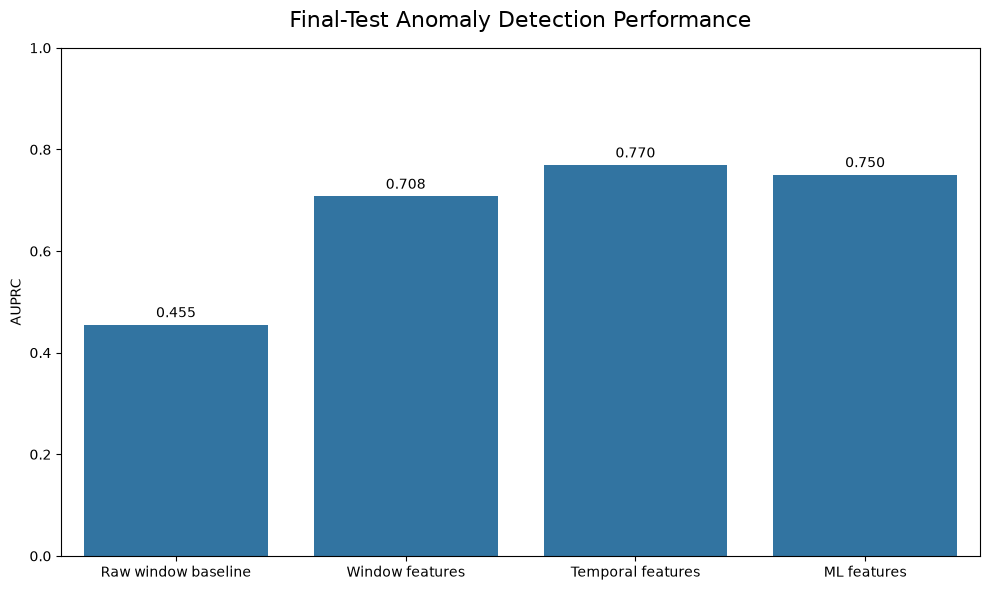

In [11]:
# ============================================================
# FINAL-TEST AUPRC
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=final_test_plot,
    x="model_label",
    y="AUPRC",
    order=[
        MODEL_LABELS[m]
        for m in MODEL_ORDER
    ],
    ax=ax,
)

ax.set_title(
    "Final-Test Anomaly Detection Performance",
    fontsize=16,
    pad=15,
)

ax.set_xlabel("")
ax.set_ylabel("AUPRC")

ax.set_ylim(0, 1)

ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
    )

plt.tight_layout()
plt.show()

## 3.&nbsp;Complete metric comparison

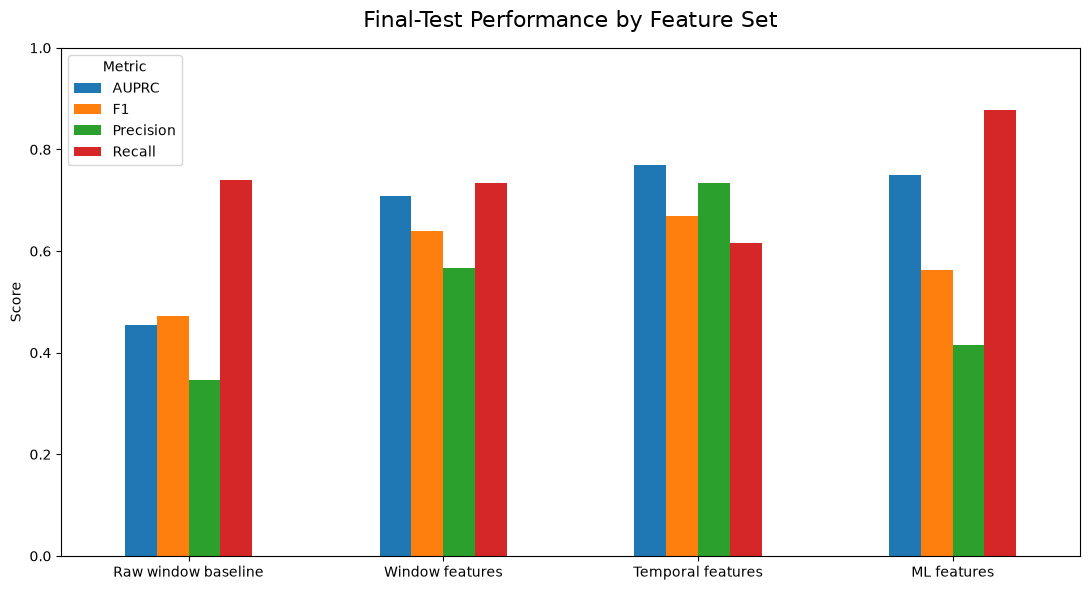

In [12]:
# ============================================================
# FINAL-TEST METRIC COMPARISON
# ============================================================

metric_columns = [
    "AUPRC",
    "F1",
    "Precision",
    "Recall",
]

metric_plot = final_test_plot[
    ["model_label"] + metric_columns
].copy()

metric_plot = metric_plot.set_index("model_label")

ax = metric_plot.plot(
    kind="bar",
    figsize=(11, 6),
)

ax.set_title(
    "Final-Test Performance by Feature Set",
    fontsize=16,
    pad=15,
)

ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

## 4.&nbsp;Validation vs. final-test AUPRC

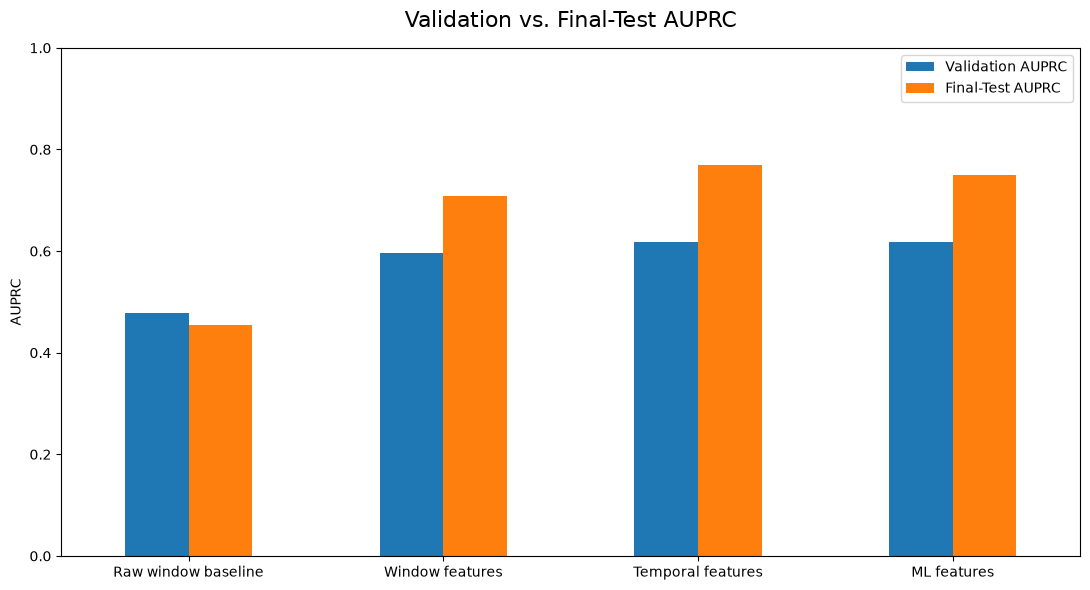

In [13]:
# ============================================================
# VALIDATION VS FINAL TEST AUPRC
# ============================================================

best_config_plot = best_configurations.copy()

best_config_plot["model_label"] = (
    best_config_plot["model"]
    .map(MODEL_LABELS)
)

best_config_plot["model"] = pd.Categorical(
    best_config_plot["model"],
    categories=MODEL_ORDER,
    ordered=True,
)

best_config_plot = (
    best_config_plot
    .sort_values("model")
    .reset_index(drop=True)
)

comparison_plot = best_config_plot[
    ["model_label", "AUPRC"]
].rename(
    columns={"AUPRC": "Validation AUPRC"}
)

comparison_plot["Final-Test AUPRC"] = (
    final_test_plot["AUPRC"].to_numpy()
)

comparison_plot = comparison_plot.set_index("model_label")

ax = comparison_plot.plot(
    kind="bar",
    figsize=(11, 6),
)

ax.set_title(
    "Validation vs. Final-Test AUPRC",
    fontsize=16,
    pad=15,
)

ax.set_xlabel("")
ax.set_ylabel("AUPRC")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.legend()

plt.tight_layout()
plt.show()

## 5.&nbsp;Hyperparameter optimization

In [14]:
# ============================================================
# BEST HYPERPARAMETER CONFIGURATIONS
# ============================================================

best_config_display = best_configurations.copy()

best_config_display["model_label"] = (
    best_config_display["model"]
    .map(MODEL_LABELS)
)

best_config_display["model"] = pd.Categorical(
    best_config_display["model"],
    categories=MODEL_ORDER,
    ordered=True,
)

best_config_display = (
    best_config_display
    .sort_values("model")
    .reset_index(drop=True)
)

best_config_display[
    [
        "model_label",
        "n_estimators",
        "max_samples",
        "max_features",
        "AUPRC",
    ]
]

,model_label,n_estimators,max_samples,max_features,AUPRC
0,Raw window baseline,200,1.00,0.50,0.477715
1,Window features,300,0.75,0.50,0.595974
2,Temporal features,200,1.00,0.75,0.618761
3,ML features,200,1.00,0.75,0.617246


## 6.&nbsp;Threshold results

In [16]:
# ============================================================
# THRESHOLD RESULTS
# ============================================================

MODEL_ORDER = [
    "baseline_raw_windows",
    "window_features",
    "temporal_features",
    "ml_features",
]

MODEL_LABELS = {
    "baseline_raw_windows": "Raw window baseline",
    "window_features": "Window features",
    "temporal_features": "Temporal features",
    "ml_features": "ML features",
}

threshold_plot = (
    threshold_results
    .copy()
    .assign(
        model_label=lambda df: df["model"].map(MODEL_LABELS),
        model_order=lambda df: pd.Categorical(
            df["model"],
            categories=MODEL_ORDER,
            ordered=True,
        ),
    )
    .sort_values("model_order")
    .reset_index(drop=True)
)

threshold_plot[
    [
        "model_label",
        "threshold",
        "precision",
        "recall",
        "f1",
    ]
]

,model_label,threshold,precision,recall,f1
0,Raw window baseline,0.412752,0.378241,0.830999,0.519860
1,Window features,0.434906,0.418115,0.853408,0.561253
2,Temporal features,0.417172,0.456150,0.747899,0.566678
3,ML features,0.385818,0.416561,0.915966,0.572680


## 7.&nbsp;Final-test confusion matrices

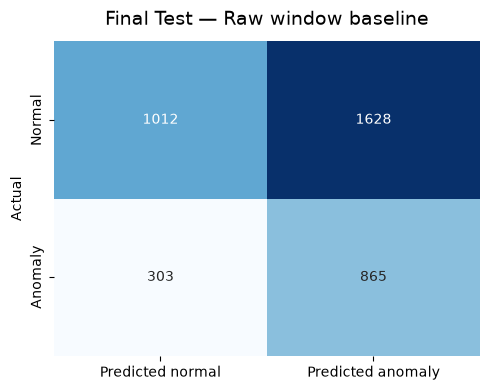

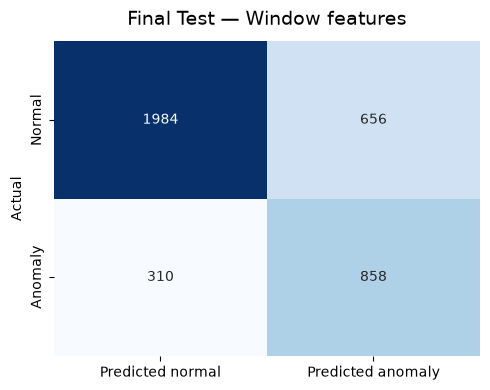

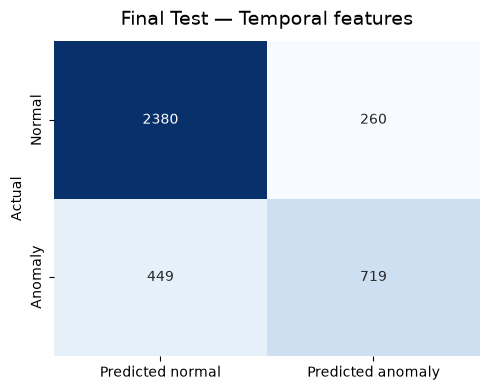

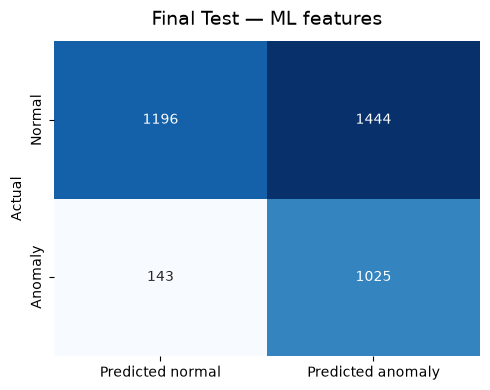

In [17]:
# ============================================================
# FINAL-TEST CONFUSION MATRICES
# ============================================================

for _, row in final_test_plot.iterrows():

    confusion_matrix = pd.DataFrame(
        [
            [row["TN"], row["FP"]],
            [row["FN"], row["TP"]],
        ],
        index=["Normal", "Anomaly"],
        columns=["Predicted normal", "Predicted anomaly"],
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        confusion_matrix,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        cbar=False,
    )

    plt.title(
        f"Final Test — {row['model_label']}",
        fontsize=14,
        pad=12,
    )

    plt.xlabel("")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

## 8.&nbsp;Explainability